In [1]:
# ── User parameters (data-independent) ─────────────────────
import os; os.makedirs('output', exist_ok=True)

MORSE_NPZ         = 'output/FN1_01/prep_riem.npz'
OUT_SWC           = 'output/FN1_01/neurons_auto.swc'
STACK_TIF         = 'output/FN1_01/stack_preprocessed.tif'

COST_TARGET_RATIO = 3000   # target cost ratio of tube vs. background
MIN_DIST_UM       = 25.0   # minimum physical distance between tips (µm)

# Fixed parameters
GAMMA         = 0.95
SIGMA_PERP    = 1.0
MAX_TIPS      = 300
MIN_RADIUS_UM = 0.1
MERGE_DOT_MIN = 0.92
MIN_TORTUOSITY = 1.02
MIN_PATH_LEN_UM_FLOOR = 5.0   # hard floor for minimum dendrite length

In [2]:
# ── Load ────────────────────────────────────────────────────
import numpy as np, time, gc

d              = np.load(MORSE_NPZ)
T_down         = d['T_down'].astype(np.float32)
radius_down    = d['radius_down'].astype(np.float32)
edt_down       = d['edt_down'].astype(np.float32)
orient_down    = d['orient_down'].astype(np.float32)
soma_mask_down = d['soma_mask_down']
voxel_down     = float(d['voxel_down'])
soma_vox_down  = d['soma_vox_down'].astype(np.float64)
soma_r_um      = float(d['soma_r_um'])
BORDER_PAD_Z   = int(d['border_pad_z']) if 'border_pad_z' in d else 1

Zd, Yd, Xd = T_down.shape
print(f'T_down      : {T_down.shape}  voxel={voxel_down:.3f} µm')
print(f'soma_r_um   : {soma_r_um:.2f} µm')
print(f'border_pad_z: {BORDER_PAD_Z} vox  ({BORDER_PAD_Z * voxel_down:.1f} µm)')

T_down      : (266, 249, 248)  voxel=1.368 µm
soma_r_um   : 10.77 µm
border_pad_z: 0 vox  (0.0 µm)


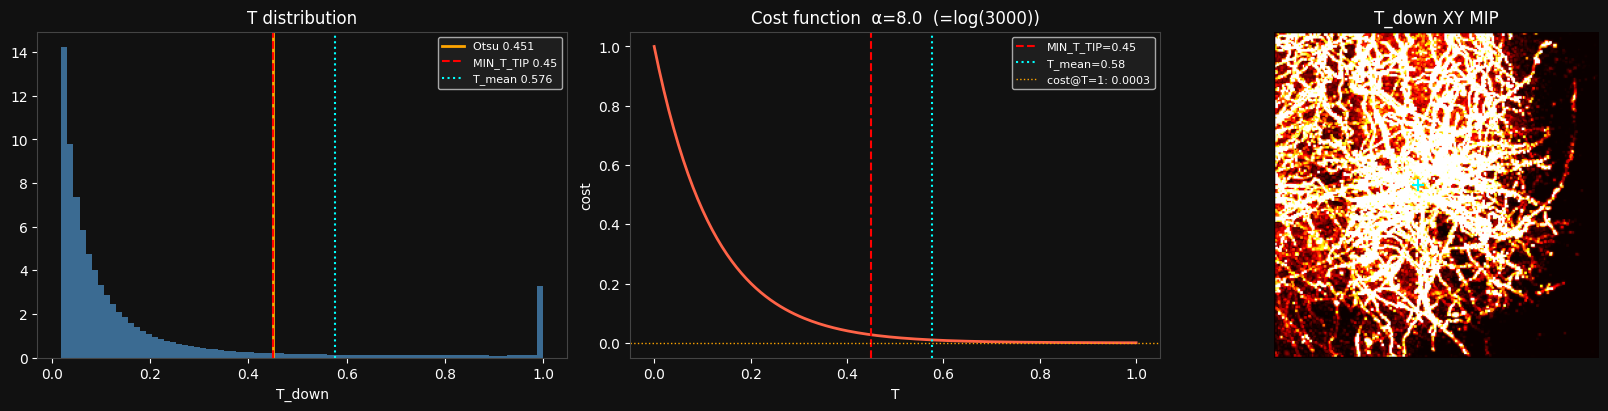

  Auto-detected parameters
  ALPHA        = 8.0     (log(3000)  cost@T=1=0.0003)
  MIN_T_TIP    = 0.45    (Otsu=0.451)
  MIN_DIST_VOX = 18      (25.0 µm / 1.368 µm/vox)
  MIN_MEAN_T   = 0.16    (MIN_T_TIP × 0.35)
  MIN_SEG_T    = 0.023   (MIN_T_TIP × 0.05)
  MIN_PATH_LEN = 5.4     µm
  MERGE_DIST   = 16.2    µm

# To override:
# MIN_T_TIP = 0.40
# ALPHA     = 8.0


In [3]:
# ── Auto-detect parameters + visualize ──────────────────────
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu

T_fg = T_down[T_down > 0.02].ravel()
otsu_val = float(threshold_otsu(T_fg))

# ── Detection ───────────────────────────────────────────────
MIN_T_TIP = round(float(np.clip(otsu_val, 0.20, 0.60)), 2)

# ALPHA: log(COST_TARGET_RATIO) — cost ratio vs. background at T=1
# Previously: divided by T_mean, but T_mean varies per dataset causing ALPHA to blow up
# Fix: defined as ratio at T=1 → log(3000) = 8.0  (data-independent)
ALPHA        = round(float(np.clip(np.log(COST_TARGET_RATIO), 4.0, 12.0)), 1)
T_mean_tube  = float(T_down[T_down > MIN_T_TIP * 0.5].mean())   # for visualization

MIN_DIST_VOX    = int(round(MIN_DIST_UM / voxel_down))
MIN_MEAN_T      = round(MIN_T_TIP * 0.35, 2)
MIN_SEG_T       = round(MIN_T_TIP * 0.05, 3)
MIN_PATH_LEN_UM = round(float(max(MIN_PATH_LEN_UM_FLOOR, soma_r_um * 0.5)), 1)
MERGE_DIST_UM   = round(float(max(10.0, soma_r_um * 1.5)), 1)

# ── visualization ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4), constrained_layout=True)
fig.patch.set_facecolor('#111111')
for ax in axes:
    ax.set_facecolor('#111111'); ax.tick_params(colors='white'); ax.spines[:].set_color('#444')

axes[0].hist(T_fg, bins=80, color='steelblue', density=True, alpha=0.8)
axes[0].axvline(otsu_val,   color='orange', lw=2,   label=f'Otsu {otsu_val:.3f}')
axes[0].axvline(MIN_T_TIP,  color='red',    lw=1.5, ls='--', label=f'MIN_T_TIP {MIN_T_TIP}')
axes[0].axvline(T_mean_tube,color='cyan',   lw=1.5, ls=':',  label=f'T_mean {T_mean_tube:.3f}')
axes[0].set_xlabel('T_down', color='white'); axes[0].set_title('T distribution', color='white')
axes[0].legend(facecolor='#222', labelcolor='white', fontsize=8)

T_range = np.linspace(0, 1, 200)
axes[1].plot(T_range, np.exp(-ALPHA * T_range), color='tomato', lw=2)
axes[1].axvline(MIN_T_TIP,   color='red',  ls='--', lw=1.5, label=f'MIN_T_TIP={MIN_T_TIP}')
axes[1].axvline(T_mean_tube, color='cyan', ls=':',  lw=1.5, label=f'T_mean={T_mean_tube:.2f}')
axes[1].axhline(np.exp(-ALPHA), color='orange', ls=':', lw=1,
                label=f'cost@T=1: {np.exp(-ALPHA):.4f}')
axes[1].set_xlabel('T', color='white'); axes[1].set_ylabel('cost', color='white')
axes[1].set_title(f'Cost function  α={ALPHA}  (=log({COST_TARGET_RATIO}))', color='white')
axes[1].legend(facecolor='#222', labelcolor='white', fontsize=8)

axes[2].imshow(T_down.max(axis=0), cmap='hot', vmin=0, vmax=1, origin='upper')
axes[2].scatter([soma_vox_down[2]], [soma_vox_down[1]], c='cyan', s=80, marker='+', zorder=5)
axes[2].set_title('T_down XY MIP', color='white'); axes[2].axis('off')
plt.show()

# ── output ─────────────────────────────────────────────────────
print('=' * 56)
print('  Auto-detected parameters')
print('=' * 56)
print(f'  ALPHA        = {ALPHA:<6}  (log({COST_TARGET_RATIO})  cost@T=1={np.exp(-ALPHA):.4f})')
print(f'  MIN_T_TIP    = {MIN_T_TIP:<6}  (Otsu={otsu_val:.3f})')
print(f'  MIN_DIST_VOX = {MIN_DIST_VOX:<6}  ({MIN_DIST_UM} µm / {voxel_down:.3f} µm/vox)')
print(f'  MIN_MEAN_T   = {MIN_MEAN_T:<6}  (MIN_T_TIP × 0.35)')
print(f'  MIN_SEG_T    = {MIN_SEG_T:<6}  (MIN_T_TIP × 0.05)')
print(f'  MIN_PATH_LEN = {MIN_PATH_LEN_UM:<6}  µm')
print(f'  MERGE_DIST   = {MERGE_DIST_UM:<6}  µm')
print('=' * 56)
print()
print('# To override:')
print('# MIN_T_TIP = 0.40')
print('# ALPHA     = 8.0')


In [4]:
# ── FileHFM setup ────────────────────────────────────────────
import agd
from agd import Eikonal, Metrics

txt = 'FileHFM_binary_dir.txt'
with open(txt) as f:
    BIN_DIR = f.read().strip()
agd.Eikonal.LibraryCall.binary_dir['FileHFM'] = BIN_DIR
print(f'FileHFM: {BIN_DIR}')
print(f'  Riemann3: {os.path.exists(os.path.join(BIN_DIR, "FileHFM_Riemann3"))}')

FileHFM: /Users/lee/Tracer/tracer_aniso/bin
  Riemann3: True


In [5]:
# ── Metric tensor M(x) ──────────────────────────────────────
t0 = time.time()
T64     = T_down.astype(np.float64)
cost2   = np.exp(-ALPHA * T64) ** 2
sigma_p = SIGMA_PERP * (1.0 - GAMMA * T64)
v       = orient_down.astype(np.float64)

M = np.zeros((3, 3, Zd, Yd, Xd), dtype=np.float64)
for i in range(3):
    M[i, i] += SIGMA_PERP
    for j in range(3):
        M[i, j] += (sigma_p - SIGMA_PERP) * v[..., i] * v[..., j]
M *= cost2[np.newaxis, np.newaxis]
del cost2, v, sigma_p, T64; gc.collect()

sp_min = SIGMA_PERP * (1.0 - GAMMA * float(T_down.max()))
print(f'M built in {time.time()-t0:.1f}s  mem={M.nbytes/1e9:.2f} GB')
print(f'Anisotropy ratio: {SIGMA_PERP/sp_min:.1f}:1  (at T=max)')

M built in 0.6s  mem=1.18 GB
Anisotropy ratio: 20.0:1  (at T=max)


In [6]:
# ── Riemannian FMM ───────────────────────────────────────────
t0 = time.time()
soma_seeds = np.argwhere(soma_mask_down).astype(np.float64)
print(f'Seeds: {len(soma_seeds):,} soma voxels')

metric = Metrics.Riemann(M)
del M; gc.collect()

hfm = Eikonal.dictIn({
    'model':        'Riemann3',
    'dims':         np.array([Zd, Yd, Xd]),
    'gridScale':    1.0,
    'metric':       metric,
    'seeds':        soma_seeds,
    'exportValues': True,
    'verbosity':    1,
})
out           = hfm.Run()
geodesic_dist = out['values'].astype(np.float32)
print(f'FMM done in {time.time()-t0:.1f}s')
print(f'Reachable: {np.isfinite(geodesic_dist).sum():,}')
print(f'Geo range: {geodesic_dist[np.isfinite(geodesic_dist)].min():.3f} – '
      f'{geodesic_dist[np.isfinite(geodesic_dist)].max():.3f}')

Seeds: 2,031 soma voxels
Field origin defaults to {0,0,0}
Field order defaults to 1
Field seedRadius defaults to 0
Fast marching solver completed in 26.5456 s.
FMM done in 40.4s
Reachable: 16,426,032
Geo range: 0.000 – 160.479


Tips detected : 378
Tips selected : 300  T=1.000–1.000


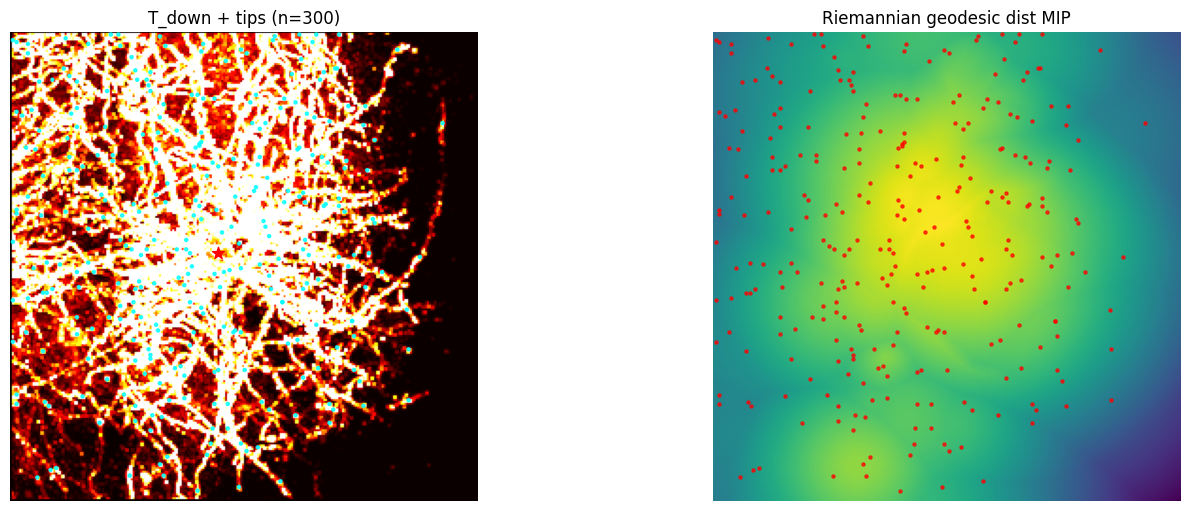

In [7]:
# ── Tip detection ────────────────────────────────────────────
from skimage.feature import peak_local_max

_peaks = peak_local_max(
    T_down,
    min_distance   = MIN_DIST_VOX,
    threshold_abs  = MIN_T_TIP,
    exclude_border = False,
)
tip_coords_all = _peaks if _peaks.dtype != bool else np.argwhere(_peaks)
tip_vals       = T_down[tip_coords_all[:,0], tip_coords_all[:,1], tip_coords_all[:,2]]
sort_idx       = np.argsort(tip_vals)[::-1]
tip_coords_s   = tip_coords_all[sort_idx][:MAX_TIPS]
tip_vals_s     = tip_vals[sort_idx][:MAX_TIPS]

reachable    = np.isfinite(geodesic_dist[tip_coords_s[:,0],
                                         tip_coords_s[:,1],
                                         tip_coords_s[:,2]])
tip_coords_s = tip_coords_s[reachable]
tip_vals_s   = tip_vals_s[reachable]

geo_finite = geodesic_dist.copy()
geo_finite[~np.isfinite(geo_finite)] = 0

print(f'Tips detected : {len(tip_coords_all):,}')
print(f'Tips selected : {len(tip_coords_s)}  T={tip_vals_s[-1]:.3f}–{tip_vals_s[0]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].imshow(T_down.max(axis=0), cmap='hot', vmin=0, vmax=1, origin='upper')
axes[0].scatter(tip_coords_s[:,2], tip_coords_s[:,1],
                s=5, c=tip_vals_s, cmap='cool', alpha=0.8)
axes[0].scatter([soma_vox_down[2]], [soma_vox_down[1]], c='red', s=80, marker='*', zorder=5)
axes[0].set_title(f'T_down + tips (n={len(tip_coords_s)})'); axes[0].axis('off')
axes[1].imshow((geo_finite/(geo_finite.max()+1e-8)).max(axis=0),
               cmap='viridis_r', origin='upper')
axes[1].scatter(tip_coords_s[:,2], tip_coords_s[:,1], s=5, c='red', alpha=0.7)
axes[1].set_title('Riemannian geodesic dist MIP'); axes[1].axis('off')
plt.show()

In [8]:
# ── Traceback: discrete gradient descent + distal trimming ───
t0 = time.time()

def traceback_discrete(tip_vox, geo_dist, soma_mask, Zd, Yd, Xd,
                       border_z=1, max_steps=200000):
    cur  = (int(tip_vox[0]), int(tip_vox[1]), int(tip_vox[2]))
    path = []
    for _ in range(max_steps):
        path.append(cur)
        if soma_mask[cur]: break
        z, y, x  = cur
        # stop when entering border zone — prevents surface shortcuts
        if len(path) > 1 and (z < border_z or z >= Zd - border_z):
            break
        best_val = geo_dist[cur]
        best_nb  = None
        for dz in range(-1, 2):
            for dy in range(-1, 2):
                for dx in range(-1, 2):
                    if dz == dy == dx == 0: continue
                    nz, ny, nx = z+dz, y+dy, x+dx
                    if 0 <= nz < Zd and 0 <= ny < Yd and 0 <= nx < Xd:
                        v = geo_dist[nz, ny, nx]
                        if v < best_val:
                            best_val, best_nb = v, (nz, ny, nx)
        if best_nb is None: break
        cur = best_nb
    return path[::-1]

def path_length_um(path, voxel):
    if len(path) < 2: return 0.0
    arr = np.array(path, dtype=np.float32)
    return float(np.linalg.norm(np.diff(arr, axis=0), axis=1).sum()) * voxel

# remove tips inside border zone
border_mask = ((tip_coords_s[:,0] >= BORDER_PAD_Z) &
               (tip_coords_s[:,0] <  Zd - BORDER_PAD_Z))
n_border_removed = (~border_mask).sum()
tip_coords_s = tip_coords_s[border_mask]
tip_vals_s   = tip_vals_s[border_mask]
if n_border_removed:
    print(f'Border tips removed: {n_border_removed}')

all_paths = {}
n_short = n_trimmed = n_too_short_trim = n_straight = 0

for i, tip in enumerate(tip_coords_s):
    key = (int(tip[0]), int(tip[1]), int(tip[2]))
    if not np.isfinite(geodesic_dist[key]): continue
    path = traceback_discrete(key, geodesic_dist, soma_mask_down,
                              Zd, Yd, Xd, border_z=BORDER_PAD_Z)

    if path_length_um(path, voxel_down) < MIN_PATH_LEN_UM:
        n_short += 1; continue

    t_vals  = np.array([T_down[k] for k in path], dtype=np.float32)
    trimmed = False
    half    = len(path) // 2

    bad = np.where(t_vals[half:] < MIN_SEG_T)[0]
    if len(bad) > 0:
        path = path[:half + bad[0]]; t_vals = t_vals[:half + bad[0]]; trimmed = True
        if path_length_um(path, voxel_down) < MIN_PATH_LEN_UM:
            n_too_short_trim += 1; continue

    if len(t_vals) > half:
        rm = np.cumsum(t_vals[half:]) / np.arange(1, len(t_vals)-half+1)
        bm = np.where(rm < MIN_MEAN_T)[0]
        if len(bm) > 0:
            path = path[:half + bm[0]]; t_vals = t_vals[:half + bm[0]]; trimmed = True
            if path_length_um(path, voxel_down) < MIN_PATH_LEN_UM:
                n_too_short_trim += 1; continue

    if trimmed: n_trimmed += 1

    path_len_um = path_length_um(path, voxel_down)
    euclid_um   = float(np.linalg.norm(
        np.array(path[-1], dtype=np.float32) -
        np.array(path[0],  dtype=np.float32))) * voxel_down
    if path_len_um / (euclid_um + 1e-8) < MIN_TORTUOSITY:
        n_straight += 1; continue

    all_paths[i] = path

print(f'Traceback : {time.time()-t0:.1f}s')
print(f'Paths kept: {len(all_paths)}')
print(f'  trimmed & kept: {n_trimmed}')
print(f'  filtered — short:{n_short}  too_short_trim:{n_too_short_trim}  straight:{n_straight}')
if all_paths:
    lens = [path_length_um(p, voxel_down) for p in all_paths.values()]
    print(f'  Length: min={min(lens):.1f}  max={max(lens):.1f}  mean={np.mean(lens):.1f} µm')

Traceback : 0.1s
Paths kept: 196
  trimmed & kept: 9
  filtered — short:104  too_short_trim:0  straight:0
  Length: min=5.7  max=147.5  mean=30.3 µm


In [9]:
# ── Build tree ──────────────────────────────────────────────
from scipy.ndimage import binary_erosion as _bin_erode

# hollow soma handling: place node 1 at soma surface centroid
# if centroid is in hollow interior, branches start from empty space causing straight-line artifacts
_soma_surface = soma_mask_down & ~_bin_erode(soma_mask_down, iterations=1)
_surf_coords  = np.argwhere(_soma_surface).astype(np.float32)
sc = _surf_coords.mean(axis=0) if len(_surf_coords) > 0 else soma_vox_down

soma_x = float(sc[2]) * voxel_down
soma_y = float(sc[1]) * voxel_down
soma_z = float(sc[0]) * voxel_down

swc_rows    = [(1, 1, soma_x, soma_y, soma_z, soma_r_um, -1)]
node_id_map = {}
next_id     = 2

sorted_keys = sorted(all_paths.keys(),
    key=lambda k: float(geo_finite[tip_coords_s[k][0],
                                   tip_coords_s[k][1],
                                   tip_coords_s[k][2]]),
    reverse=False)

for bi in sorted_keys:
    prev_swc_id = 1
    for key in all_paths[bi]:
        if soma_mask_down[key]:
            node_id_map[key] = 1; prev_swc_id = 1; continue
        if key in node_id_map:
            prev_swc_id = node_id_map[key]; continue
        z, y, x = key
        r = max(float(edt_down[z, y, x]), MIN_RADIUS_UM)
        swc_rows.append((next_id, 3,
                         x*voxel_down, y*voxel_down, z*voxel_down,
                         r, prev_swc_id))
        node_id_map[key] = next_id; prev_swc_id = next_id; next_id += 1

print(f'SWC nodes: {next_id-1:,}  (branches: {len(all_paths)})')
print(f'Node 1 (soma): ({soma_x:.1f}, {soma_y:.1f}, {soma_z:.1f}) µm  '
      f'[surface centroid, {len(_surf_coords):,} surface voxels]')
swc_rows_dict = {r[0]: r for r in swc_rows}

SWC nodes: 3,054  (branches: 196)
Node 1 (soma): (150.1, 159.4, 90.6) µm  [surface centroid, 692 surface voxels]


In [10]:
# ── Primary merge ────────────────────────────────────────────
from scipy.spatial import cKDTree
from collections import defaultdict

primary_nodes = {nid: swc_rows_dict[nid]
                 for nid in [r[0] for r in swc_rows if r[6] == 1]}

def branch_dir(nid):
    n = swc_rows_dict[nid]; sc_ = swc_rows_dict[1]
    v = np.array([n[2]-sc_[2], n[3]-sc_[3], n[4]-sc_[4]])
    return v / (np.linalg.norm(v) + 1e-8)

def node_pos(nid):
    n = swc_rows_dict[nid]; return np.array([n[2], n[3], n[4]])

pids   = list(primary_nodes.keys())
p_pos  = np.array([node_pos(p) for p in pids])
p_dirs = np.array([branch_dir(p) for p in pids])

parent_uf = {p: p for p in pids}
def find(x):
    while parent_uf[x] != x: parent_uf[x] = parent_uf[parent_uf[x]]; x = parent_uf[x]
    return x
def union(a, b): parent_uf[find(a)] = find(b)

if len(pids) > 1:
    for i, j in cKDTree(p_pos).query_pairs(MERGE_DIST_UM):
        if abs(float(p_dirs[i] @ p_dirs[j])) >= MERGE_DOT_MIN:
            union(pids[i], pids[j])

groups = defaultdict(list)
for p in pids: groups[find(p)].append(p)

def subtree_tip_count(nid):
    count, stack = 0, [nid]
    while stack:
        cur = stack.pop()
        kids = [r[0] for r in swc_rows if r[6] == cur]
        if not kids: count += 1
        stack.extend(kids)
    return count

to_remove, merged_count = set(), 0
for rep, members in groups.items():
    if len(members) == 1: continue
    best = max(members, key=subtree_tip_count)
    for m in members:
        if m != best: to_remove.add(m)
    merged_count += len(members) - 1

def get_subtree_ids(root):
    result, stack = set(), [root]
    while stack:
        cur = stack.pop(); result.add(cur)
        stack.extend([r[0] for r in swc_rows if r[6] == cur])
    return result

remove_ids = set()
for nid in to_remove: remove_ids |= get_subtree_ids(nid)
swc_rows = [r for r in swc_rows if r[0] not in remove_ids]

print(f'Primary before merge : {len(pids)}')
print(f'Merged (removed)     : {merged_count}')
print(f'SWC nodes after merge: {len(swc_rows):,}')

Primary before merge : 173
Merged (removed)     : 22
SWC nodes after merge: 2,609


In [11]:
# ── Save ─────────────────────────────────────────────────────
header = [
    f'# tracer_aniso AUTO — Riemannian FMM',
    f'# ALPHA={ALPHA}  MIN_T_TIP={MIN_T_TIP}  GAMMA={GAMMA}  SIGMA_PERP={SIGMA_PERP}',
    f'# MIN_SEG_T={MIN_SEG_T}  MIN_MEAN_T={MIN_MEAN_T}  MIN_TORTUOSITY={MIN_TORTUOSITY}',
    f'# tips={len(tip_coords_s)}  paths={len(all_paths)}  nodes={next_id-1}',
    '# id type x y z radius parent',
]
lines = header + [
    f'{r[0]} {r[1]} {r[2]:.4f} {r[3]:.4f} {r[4]:.4f} {r[5]:.4f} {r[6]}'
    for r in swc_rows
]
with open(OUT_SWC, 'w') as f:
    f.write('\n'.join(lines) + '\n')
print(f'Saved: {OUT_SWC}')

Saved: output/FN1_01/neurons_auto.swc


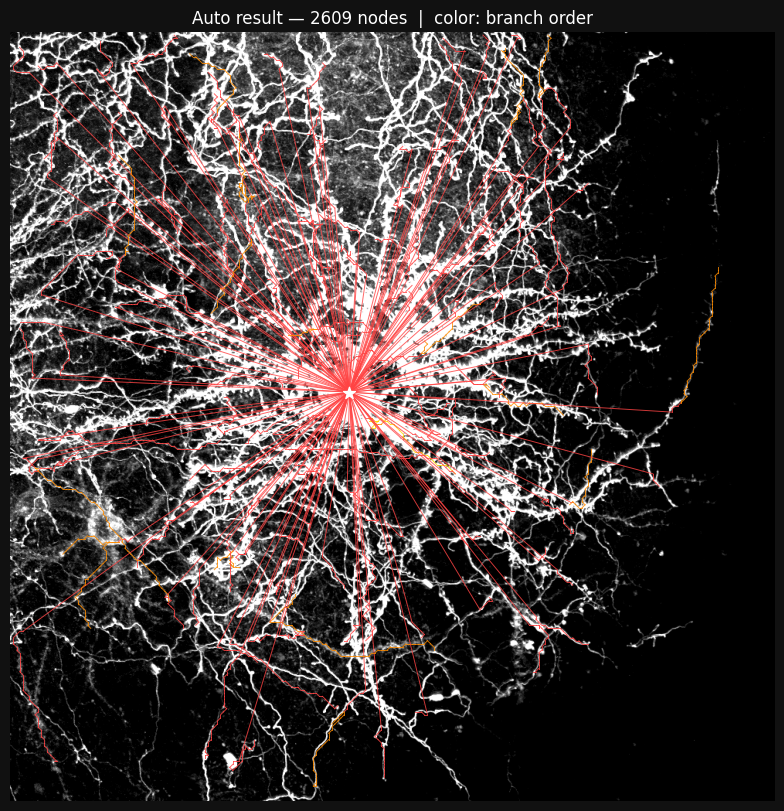

SWC nodes : 2,609
X: 1–313  Y: 1–334  Z: 10–347 µm


In [12]:
# ── Quick viz: MIP overlay ───────────────────────────────────
import tifffile

with open(OUT_SWC) as f:
    lines = [l for l in f if not l.startswith('#') and l.strip()]
nodes = np.array([list(map(float, l.split()[2:5])) for l in lines])
types = np.array([int(l.split()[1]) for l in lines])
swc_dict = {int(l.split()[0]): list(map(float, l.split()[2:6])) + [int(l.split()[6])]
            for l in lines}

stack     = tifffile.imread(STACK_TIF).astype(np.float32)
voxel_iso = float(np.load(MORSE_NPZ)['voxel_iso'])
mip_xy    = stack.max(axis=0) / stack.max()
del stack

ORDER_COLORS = {0:'#888',1:'#FF4444',2:'#FF8C00',3:'#FFD700',4:'#44BB44',5:'#4488FF'}
def order_color(o): return ORDER_COLORS.get(min(o,5),'#88AAFF')

from collections import defaultdict
children_map = defaultdict(list)
for nid_str, vals in swc_dict.items():
    par = int(vals[4])
    if par != -1: children_map[par].append(nid_str)
branch_order = {1: 0}
queue = [1]
while queue:
    cur  = queue.pop(0)
    kids = children_map.get(cur, [])
    for ch in kids:
        branch_order[ch] = branch_order[cur] + (1 if len(kids) >= 2 else 0)
        queue.append(ch)

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
fig.patch.set_facecolor('#111111')
ax.imshow(mip_xy, cmap='gray', origin='upper', vmin=0, vmax=0.8)
ax.axis('off')
for nid, vals in swc_dict.items():
    par = int(vals[4])
    if par == -1 or par not in swc_dict: continue
    p    = swc_dict[par]
    o    = branch_order.get(nid, 0)
    ax.plot([vals[0]/voxel_iso, p[0]/voxel_iso],
            [vals[1]/voxel_iso, p[1]/voxel_iso],
            '-', color=order_color(o), lw=0.7, alpha=0.8)
ax.scatter([soma_vox_down[2]*voxel_down/voxel_iso],
           [soma_vox_down[1]*voxel_down/voxel_iso],
           c='white', s=80, marker='*', zorder=5)
ax.set_title(f'Auto result — {len(swc_dict)} nodes  |  color: branch order',
             color='white')
fig.patch.set_facecolor('#111111')
plt.show()

den = nodes[types==3]; som = nodes[types==1]
print(f'SWC nodes : {len(nodes):,}')
print(f'X: {nodes[:,0].min():.0f}–{nodes[:,0].max():.0f}  '
      f'Y: {nodes[:,1].min():.0f}–{nodes[:,1].max():.0f}  '
      f'Z: {nodes[:,2].min():.0f}–{nodes[:,2].max():.0f} µm')